In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from metrics import truthfulness, cognitive_dissonance, normalize_each_row_sum, calculate_beliefs
import networkx as nx

(100, 100)


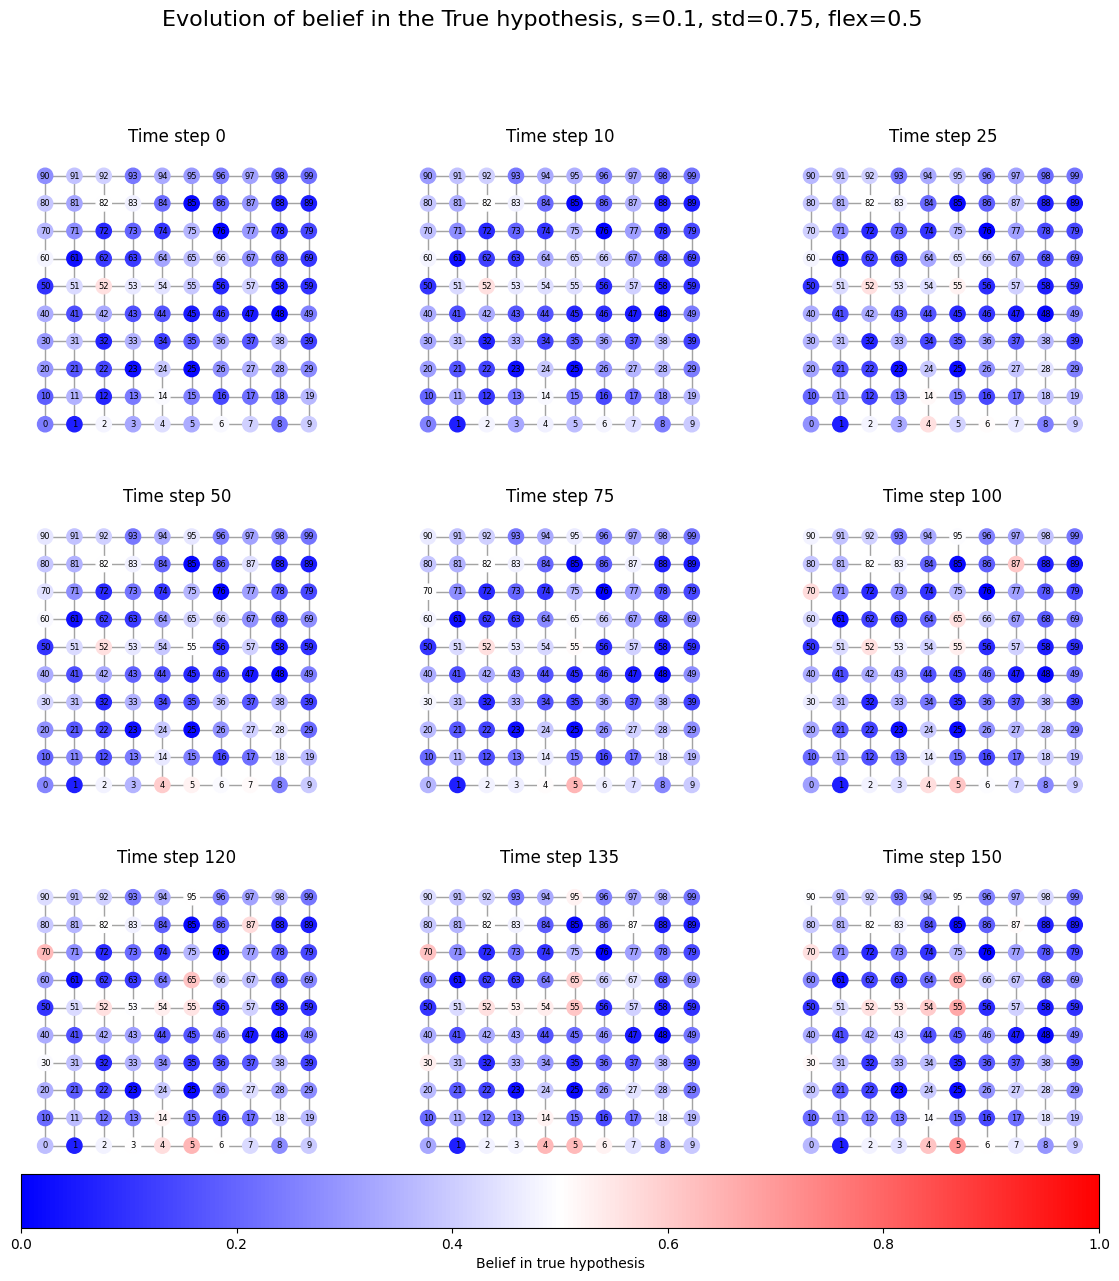

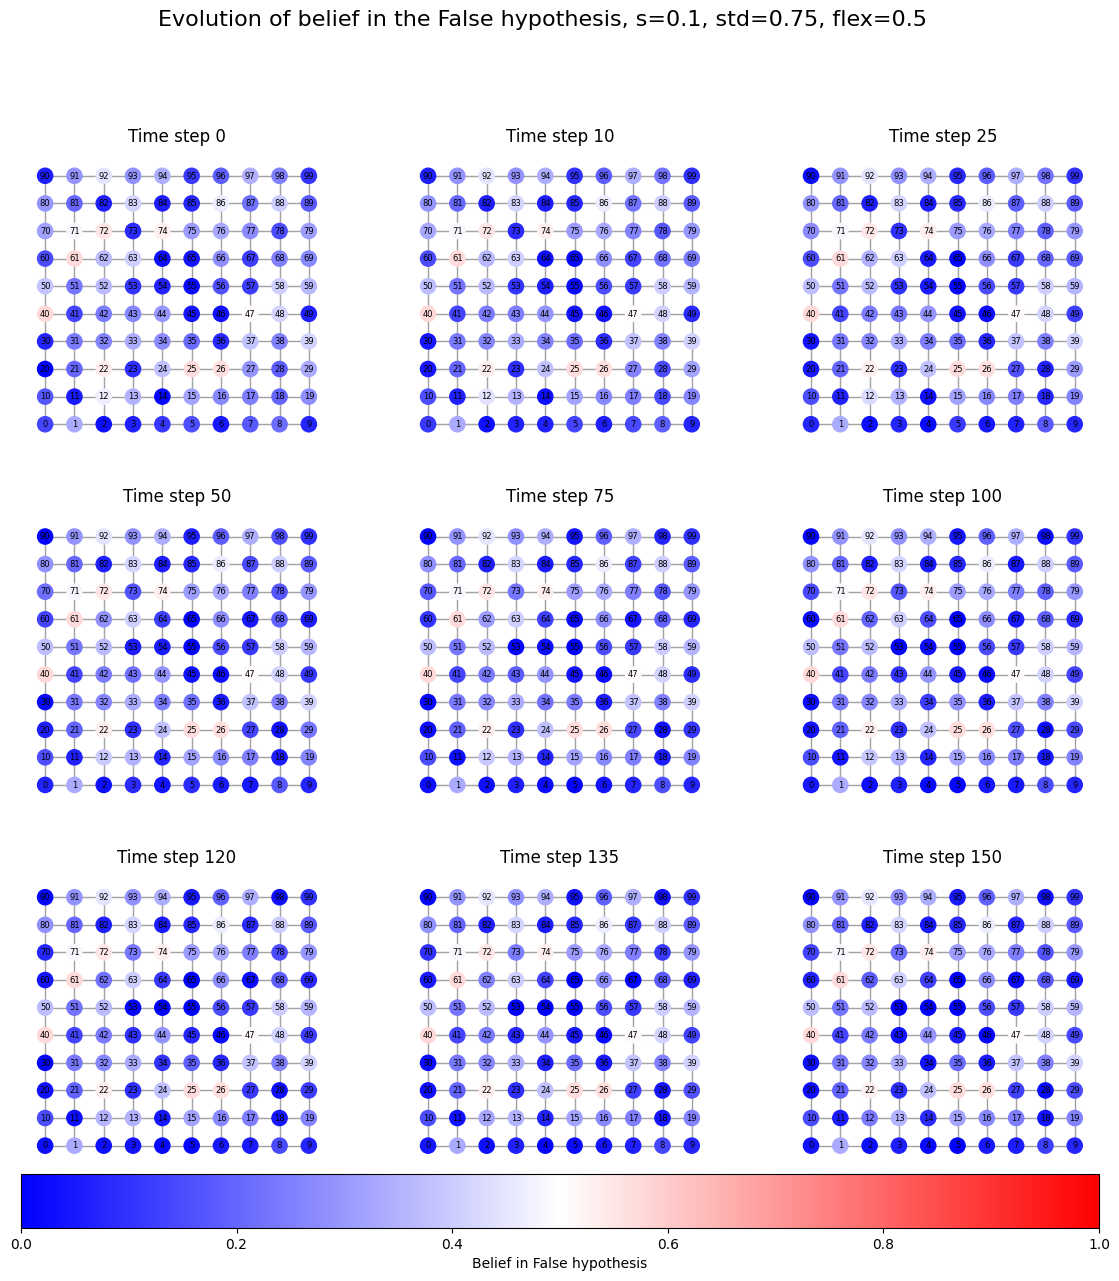

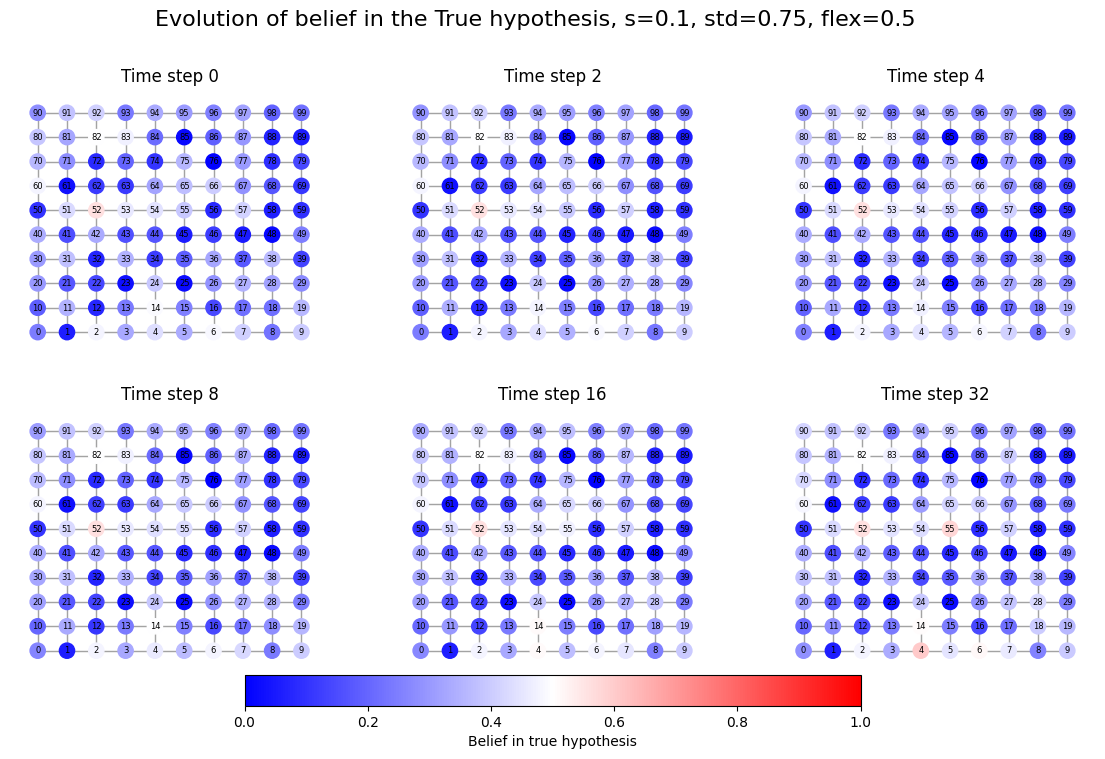

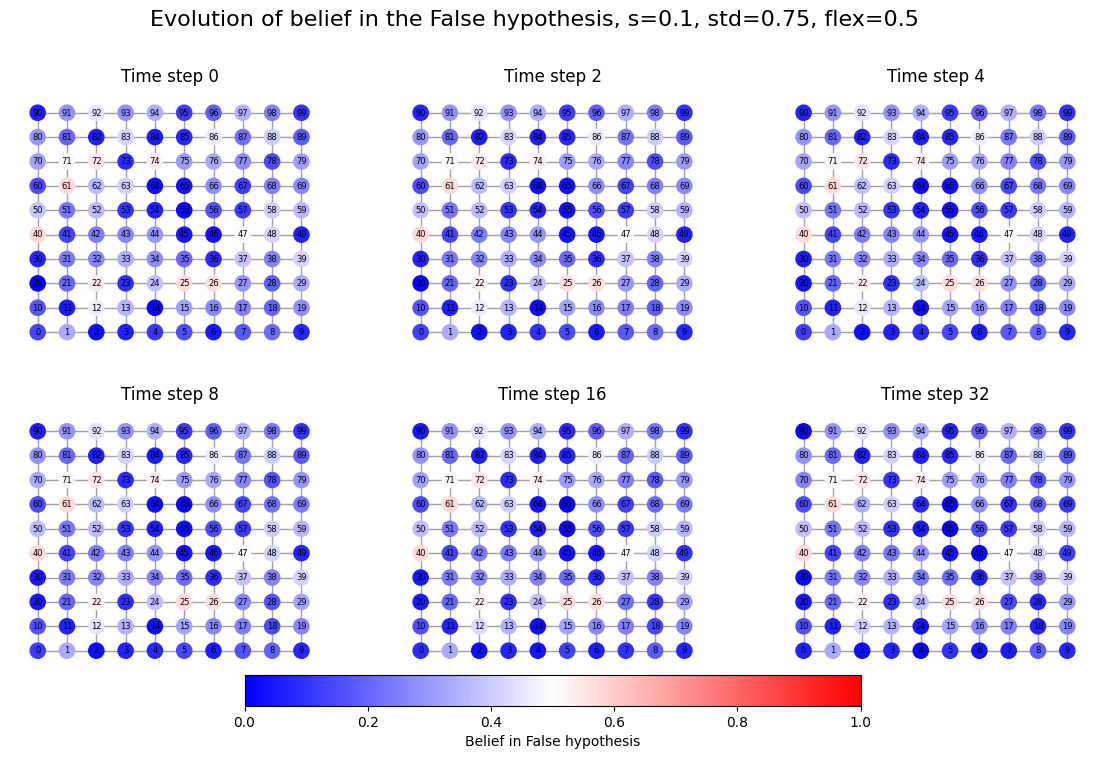

In [21]:
# --- Load your chosen file ---
s=0.1
file_name = "DHT_N100_SQUARE_S0p1_flex0p5_gaussian-stds075_T150_1sims_1"
graph_file_name = "GRAPH-" + file_name
dir = "visualization"
plot_dir = "plots"
file_path = os.path.join(dir, file_name + ".npz")
data = np.load(file_path)
graph_path = os.path.join(dir, graph_file_name + ".npz")
graph = np.load(graph_path)

# Extract relevant arrays
private_beliefs = data["private"]  # shape (T, N)
adj_matrix = graph['arr_0'][0]
print(adj_matrix.shape)  # should print 50

# --- Rebuild the graph from adjacency matrix ---
if adj_matrix is not None:
    G = nx.grid_2d_graph(int((np.sqrt(adj_matrix.shape[0]))), int((np.sqrt(adj_matrix.shape[0]))), periodic=True)
else:
    # if not saved, you can regenerate using your graph function
    raise ValueError("Adjacency matrix not found in the NPZ file.")

# --- Compute truthfulness ---
T = calculate_beliefs(private_beliefs, 3)  # shape (T, N), values 0–1
F = calculate_beliefs(private_beliefs, 0)

# T = data["T3"]
# F = data["T0"]

# --- Choose 6 time steps evenly spaced ---
num_timesteps = T.shape[0]
selected_ts = np.array([0, 10, 25, 50, 75, 100, 120, 135, 150])
small_selected_ts = np.array([0, 2, 4, 8, 16, 32])

# --- Layout (fixed for consistency) ---
pos = {(i, j): (i, j) for i, j in G.nodes()}
G = nx.convert_node_labels_to_integers(G)
pos = {n: (n % int((np.sqrt(adj_matrix.shape[0]))), n // int((np.sqrt(adj_matrix.shape[0])))) for n in range(G.number_of_nodes())}

selected_agents = np.random.choice(int((adj_matrix.shape[0])), 5, replace=False)
timesteps = np.arange(T.shape[0])

# Plot beliefs for True hypothesis (3)
# plt.figure(figsize=(10, 6))
# for agent in selected_agents:
#     plt.plot(timesteps, T[:, agent], alpha=0.5, label=f"Agent {agent}")
# plt.title(f"Evolution of belief in the True hypothesis, s={s}, std=0.75, flex=0.5")
# plt.xlabel("Time step")
# plt.ylabel("Belief in True Hypothesis")
# plt.ylim(0, 1)
# plt.grid(True, alpha=0.3)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# plt.tight_layout()
# plt.savefig(os.path.join(dir, plot_dir, f"Belief_Evolution_True-hyp_{file_name}.png"))
# plt.show()

# # Plot beliefs for False hypothesis (0)
# plt.figure(figsize=(10, 6))
# for agent in selected_agents:
#     plt.plot(timesteps, F[:, agent], alpha=0.5, label=f"Agent {agent}")
# plt.title(f"Evolution of belief in the False hypothesis, s={s}, std=0.75, flex=0.5")
# plt.xlabel("Time step")
# plt.ylabel("Belief in False Hypothesis")
# plt.ylim(0, 1)
# plt.grid(True, alpha=0.3)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# plt.tight_layout()
# plt.savefig(os.path.join(dir, plot_dir, f"Belief_Evolution_False-hyp_{file_name}.png"))
# plt.show()

# --- Plot ---
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()
fig.suptitle(f"Evolution of belief in the True hypothesis, s={s}, std=0.75, flex=0.5", fontsize=16)

vmin, vmax = 0, 1  # color scale for truthfulness
for i, t in enumerate(selected_ts):
    node_colors = T[t]
    ax = axes[i]
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, cmap="bwr",
        vmin=vmin, vmax=vmax, node_size=120, ax=ax
    )
    nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in G.nodes()},  # label with node index
    font_size=6,
    font_color="black",
    ax=ax
    )
    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
    ax.set_title(f"Time step {t}")
    ax.axis("off")

# --- Shared colorbar ---
sm = plt.cm.ScalarMappable(cmap="bwr", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Belief in true hypothesis")
plt.savefig(os.path.join(dir, plot_dir, f"TRUE_BELIEF_ts{np.min(selected_ts)}-{np.max(selected_ts)}" + graph_file_name + ".png"))
plt.subplots_adjust(bottom=0.15) 
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()
fig.suptitle(f"Evolution of belief in the False hypothesis, s={s}, std=0.75, flex=0.5", fontsize=16)

vmin, vmax = 0, 1  # color scale for truthfulness
for i, t in enumerate(selected_ts):
    node_colors = F[t]
    ax = axes[i]
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, cmap="bwr",
        vmin=vmin, vmax=vmax, node_size=120, ax=ax
    )
    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
    nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in G.nodes()},  # label with node index
    font_size=6,
    font_color="black",
    ax=ax
    )
    ax.set_title(f"Time step {t}")
    ax.axis("off")

# --- Shared colorbar ---
sm = plt.cm.ScalarMappable(cmap="bwr", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Belief in False hypothesis")
plt.savefig(os.path.join(dir, plot_dir, f"False_BELIEF_ts{np.min(selected_ts)}-{np.max(selected_ts)}" + graph_file_name + ".png"))
plt.subplots_adjust(bottom=0.15) 
plt.show()

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
fig.suptitle(f"Evolution of belief in the True hypothesis, s={s}, std=0.75, flex=0.5", fontsize=16)

vmin, vmax = 0, 1  # color scale for truthfulness
for i, t in enumerate(small_selected_ts):
    node_colors = T[t]
    ax = axes[i]
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, cmap="bwr",
        vmin=vmin, vmax=vmax, node_size=120, ax=ax
    )
    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
    nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in G.nodes()},  # label with node index
    font_size=6,
    font_color="black",
    ax=ax
    )
    ax.set_title(f"Time step {t}")
    ax.axis("off")

# --- Shared colorbar ---
sm = plt.cm.ScalarMappable(cmap="bwr", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Belief in true hypothesis")
plt.savefig(os.path.join(dir, plot_dir, f"TRUE_BELIEF_ts{np.min(small_selected_ts)}-{np.max(small_selected_ts)}" + graph_file_name + ".png"))
plt.subplots_adjust(bottom=0.15) 
plt.show()

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
fig.suptitle(f"Evolution of belief in the False hypothesis, s={s}, std=0.75, flex=0.5", fontsize=16)

vmin, vmax = 0, 1  # color scale for truthfulness
for i, t in enumerate(small_selected_ts):
    node_colors = F[t]
    ax = axes[i]
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, cmap="bwr",
        vmin=vmin, vmax=vmax, node_size=120, ax=ax
    )
    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
    nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in G.nodes()},  # label with node index
    font_size=6,
    font_color="black",
    ax=ax
    )
    ax.set_title(f"Time step {t}")
    ax.axis("off")

# --- Shared colorbar ---
sm = plt.cm.ScalarMappable(cmap="bwr", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Belief in False hypothesis")
plt.savefig(os.path.join(dir, plot_dir, f"False_BELIEF_ts{np.min(small_selected_ts)}-{np.max(small_selected_ts)}" + graph_file_name + ".png"))
plt.subplots_adjust(bottom=0.15) 
plt.show()

(100, 100)


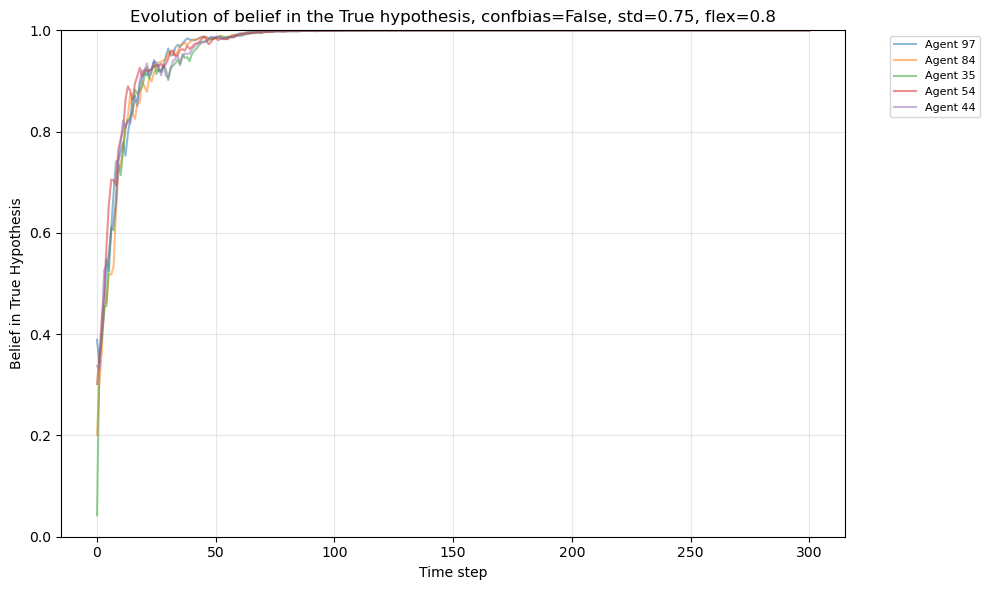

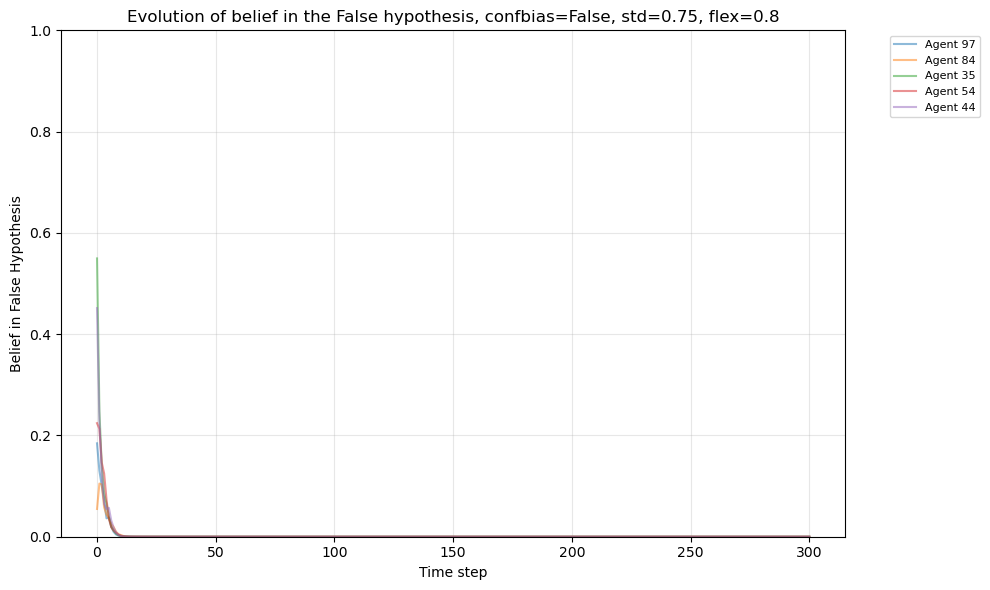

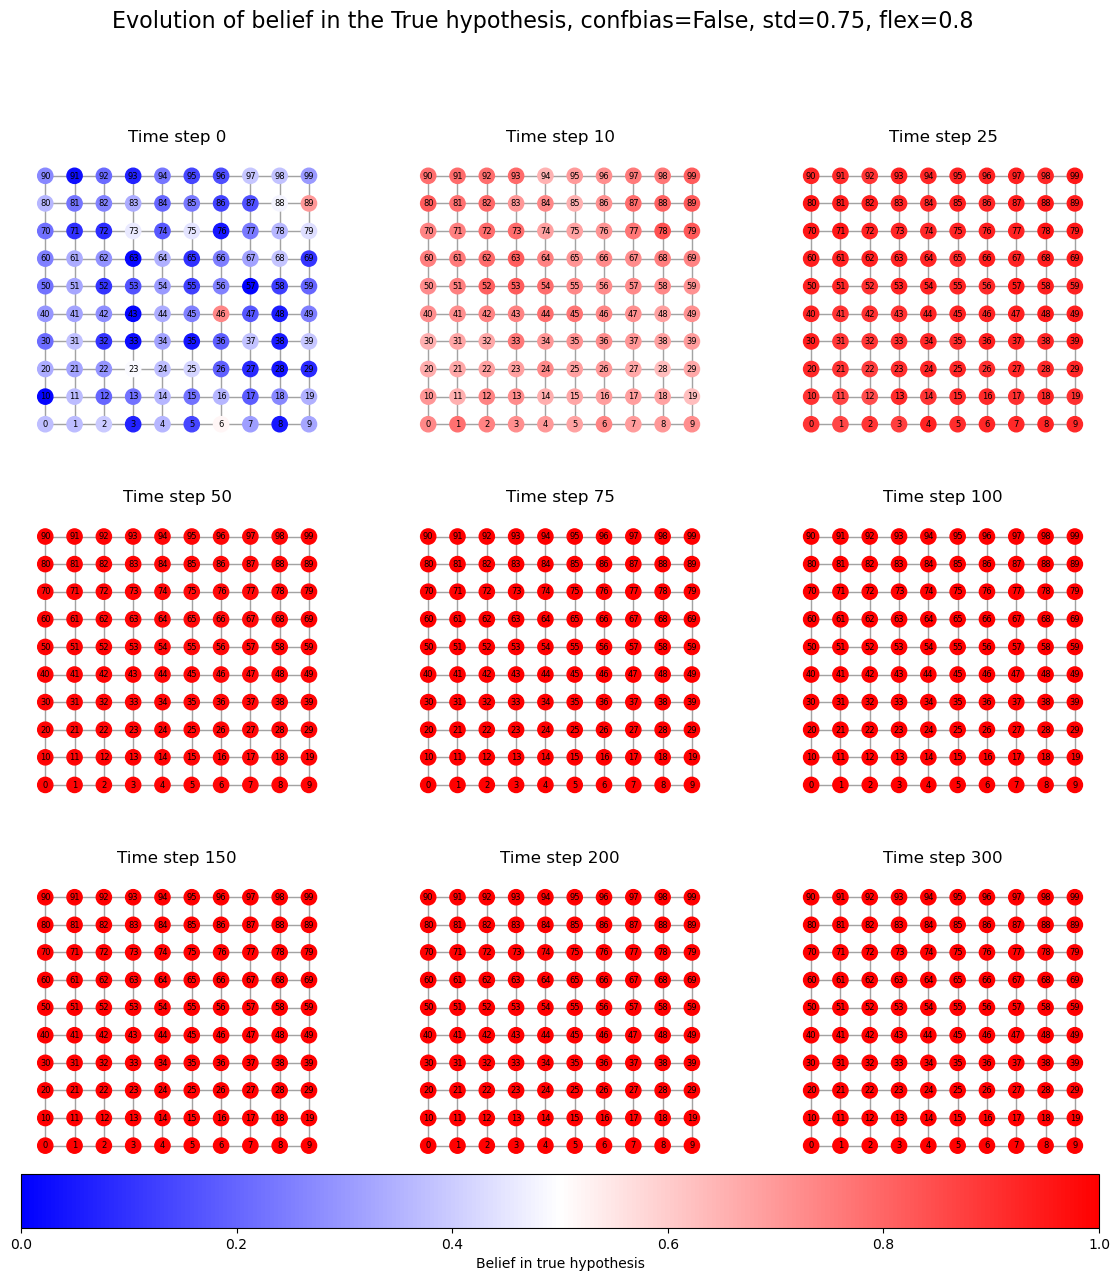

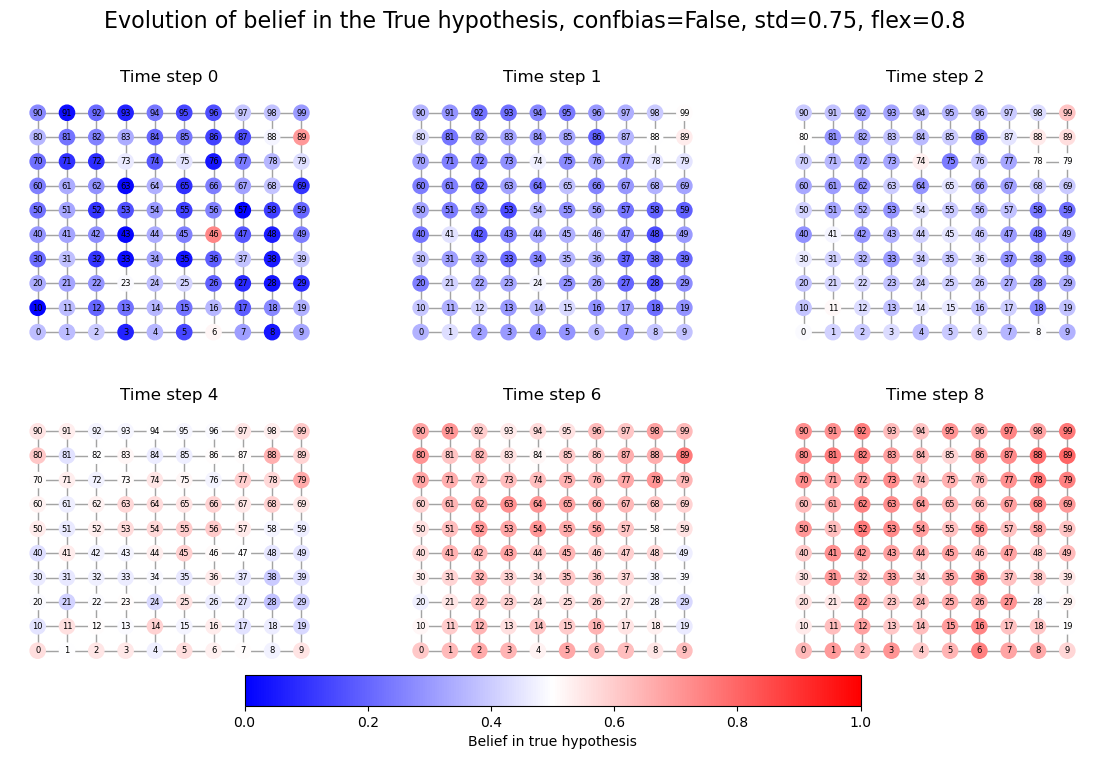

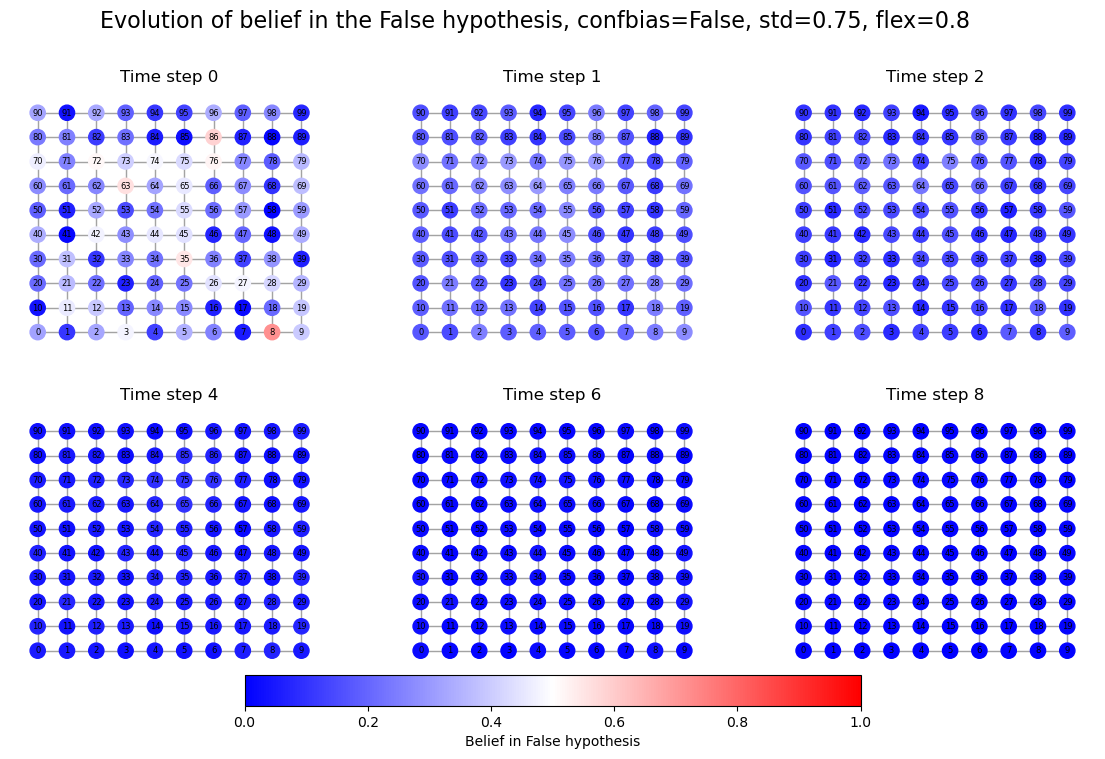

In [51]:
# --- Load your chosen file ---
file_name = "DHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_08flex_confbias-False_T300_1sims_1"
graph_file_name = "GRAPH-" + file_name
dir = "visualization"
plot_dir = "plots"
file_path = os.path.join(dir, file_name + ".npz")
data = np.load(file_path)
graph_path = os.path.join(dir, graph_file_name + ".npz")
graph = np.load(graph_path)

# Extract relevant arrays
private_beliefs = data["private"]  # shape (T, N)
adj_matrix = graph['arr_0'][0]
print(adj_matrix.shape)  # should print 50

# --- Rebuild the graph from adjacency matrix ---
if adj_matrix is not None:
    G = nx.grid_2d_graph(int((np.sqrt(adj_matrix.shape[0]))), int((np.sqrt(adj_matrix.shape[0]))), periodic=True)
else:
    # if not saved, you can regenerate using your graph function
    raise ValueError("Adjacency matrix not found in the NPZ file.")

# --- Compute truthfulness ---
T = calculate_beliefs(private_beliefs, 3)  # shape (T, N), values 0–1
F = calculate_beliefs(private_beliefs, 0)

# --- Choose 6 time steps evenly spaced ---
num_timesteps = T.shape[0]
selected_ts = np.array([0, 10, 25, 50, 75, 100, 150, 200, 300])
small_selected_ts = np.array([0, 1, 2, 4, 6, 8])

# --- Layout (fixed for consistency) ---
pos = {(i, j): (i, j) for i, j in G.nodes()}
G = nx.convert_node_labels_to_integers(G)
pos = {n: (n % int((np.sqrt(adj_matrix.shape[0]))), n // int((np.sqrt(adj_matrix.shape[0])))) for n in range(G.number_of_nodes())}

selected_agents = np.random.choice(int((adj_matrix.shape[0])), 5, replace=False)
timesteps = np.arange(T.shape[0])

# Plot beliefs for True hypothesis (3)
plt.figure(figsize=(10, 6))
for agent in selected_agents:
    plt.plot(timesteps, T[:, agent], alpha=0.5, label=f"Agent {agent}")
plt.title(f"Evolution of belief in the True hypothesis, confbias=False, std=0.75, flex=0.8")
plt.xlabel("Time step")
plt.ylabel("Belief in True Hypothesis")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(dir, plot_dir, f"Belief_Evolution_True-hyp_{file_name}.png"))
plt.show()

# Plot beliefs for False hypothesis (0)
plt.figure(figsize=(10, 6))
for agent in selected_agents:
    plt.plot(timesteps, F[:, agent], alpha=0.5, label=f"Agent {agent}")
plt.title(f"Evolution of belief in the False hypothesis, confbias=False, std=0.75, flex=0.8")
plt.xlabel("Time step")
plt.ylabel("Belief in False Hypothesis")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(dir, plot_dir, f"Belief_Evolution_False-hyp_{file_name}.png"))
plt.show()

# --- Plot ---
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()
fig.suptitle(f"Evolution of belief in the True hypothesis, confbias=False, std=0.75, flex=0.8", fontsize=16)

vmin, vmax = 0, 1  # color scale for truthfulness
for i, t in enumerate(selected_ts):
    node_colors = T[t]
    ax = axes[i]
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, cmap="bwr",
        vmin=vmin, vmax=vmax, node_size=120, ax=ax
    )
    nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in G.nodes()},  # label with node index
    font_size=6,
    font_color="black",
    ax=ax
    )
    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
    ax.set_title(f"Time step {t}")
    ax.axis("off")

# --- Shared colorbar ---
sm = plt.cm.ScalarMappable(cmap="bwr", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Belief in true hypothesis")
plt.savefig(os.path.join(dir, plot_dir, f"TRUE_BELIEF_ts{np.min(selected_ts)}-{np.max(selected_ts)}" + graph_file_name + ".png"))
plt.subplots_adjust(bottom=0.15) 
plt.show()

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
fig.suptitle(f"Evolution of belief in the True hypothesis, confbias=False, std=0.75, flex=0.8", fontsize=16)

vmin, vmax = 0, 1  # color scale for truthfulness
for i, t in enumerate(small_selected_ts):
    node_colors = T[t]
    ax = axes[i]
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, cmap="bwr",
        vmin=vmin, vmax=vmax, node_size=120, ax=ax
    )
    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
    nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in G.nodes()},  # label with node index
    font_size=6,
    font_color="black",
    ax=ax
    )
    ax.set_title(f"Time step {t}")
    ax.axis("off")

# --- Shared colorbar ---
sm = plt.cm.ScalarMappable(cmap="bwr", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Belief in true hypothesis")
plt.savefig(os.path.join(dir, plot_dir, f"TRUE_BELIEF_ts{np.min(small_selected_ts)}-{np.max(small_selected_ts)}" + graph_file_name + ".png"))
plt.subplots_adjust(bottom=0.15) 
plt.show()

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
fig.suptitle(f"Evolution of belief in the False hypothesis, confbias=False, std=0.75, flex=0.8", fontsize=16)

vmin, vmax = 0, 1  # color scale for truthfulness
for i, t in enumerate(small_selected_ts):
    node_colors = F[t]
    ax = axes[i]
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, cmap="bwr",
        vmin=vmin, vmax=vmax, node_size=120, ax=ax
    )
    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
    nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in G.nodes()},  # label with node index
    font_size=6,
    font_color="black",
    ax=ax
    )
    ax.set_title(f"Time step {t}")
    ax.axis("off")

# --- Shared colorbar ---
sm = plt.cm.ScalarMappable(cmap="bwr", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Belief in False hypothesis")
plt.savefig(os.path.join(dir, plot_dir, f"False_BELIEF_ts{np.min(small_selected_ts)}-{np.max(small_selected_ts)}" + graph_file_name + ".png"))
plt.subplots_adjust(bottom=0.15) 
plt.show()